In [1]:
pip install pandas numpy matplotlib seaborn scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
df = pd.read_csv("Food_Delivery_Times.csv")

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

In [6]:
import pandas as pd

df = pd.read_csv("Food_Delivery_Times.csv")

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [7]:
print("Shape:", df.shape)

df.info()

df.describe(include="all")

Shape: (1000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970,970,970,1000,1000.000000,970.000000,1000.000000
unique,NaN,NaN,5,3,4,3,NaN,NaN,NaN
top,NaN,NaN,Clear,Medium,Morning,Bike,NaN,NaN,NaN
freq,NaN,NaN,470,390,308,503,NaN,NaN,NaN
mean,500.500000,10.059970,NaN,NaN,NaN,NaN,16.982000,4.579381,56.732000
std,288.819436,5.696656,NaN,NaN,NaN,NaN,7.204553,2.914394,22.070915
min,1.000000,0.590000,NaN,NaN,NaN,NaN,5.000000,0.000000,8.000000
25%,250.750000,5.105000,NaN,NaN,NaN,NaN,11.000000,2.000000,41.000000
50%,500.500000,10.190000,NaN,NaN,NaN,NaN,17.000000,5.000000,55.500000
75%,750.250000,15.017500,NaN,NaN,NaN,NaN,23.000000,7.000000,71.000000


In [8]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [10]:
df["Expected_Time"] = (
    df["Preparation_Time_min"] +
    (df["Distance_km"] * 2)
)

In [11]:
df["Delay_Minutes"] = (
    df["Delivery_Time_min"] -
    df["Expected_Time"]
)

df["Delay_Minutes"] = df["Delay_Minutes"].clip(lower=0)

df[["Delivery_Time_min","Expected_Time","Delay_Minutes"]].head()

,Delivery_Time_min,Expected_Time,Delay_Minutes
0,43,27.86,15.14
1,84,52.84,31.16
2,59,47.04,11.96
3,37,19.88,17.12
4,68,54.06,13.94


In [12]:
delay_mean = df["Delay_Minutes"].mean()
delay_mean

np.float64(19.63204)

In [13]:
delay_median = df["Delay_Minutes"].median()
delay_median

np.float64(17.32)

In [14]:
df["Delay_Minutes"].mode()

0    0.0
Name: Delay_Minutes, dtype: float64

In [15]:
df["Delay_Minutes"].std()

np.float64(13.294774931486387)

In [16]:
%whos

Variable       Type         Data/Info
-------------------------------------
delay_mean     float64      19.63204
delay_median   float64      17.32
df             DataFrame    Shape: (1000, 11)
np             module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd             module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
plt            module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
sns            module       <module 'seaborn' from 'C<...>s\\seaborn\\__init__.py'>
stats          module       <module 'scipy.stats' fro<...>ipy\\stats\\__init__.py'>


In [17]:
import os

os.getcwd()

'C:\\Users\\nithi'

In [18]:
df["Delay_Minutes"].var()

np.float64(176.75104047887888)

In [19]:
df["Delay_Minutes"].quantile([0.25,0.50,0.75])

0.25    10.43
0.50    17.32
0.75    25.34
Name: Delay_Minutes, dtype: float64

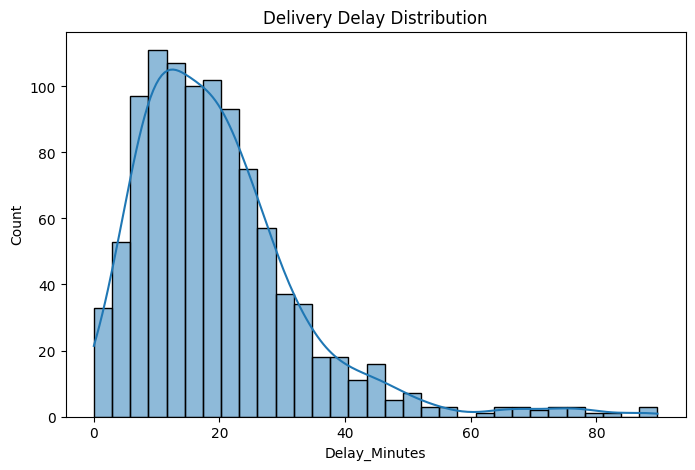

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Delay_Minutes"],
    kde=True
)

plt.title("Delivery Delay Distribution")
plt.show()

In [21]:
if delay_mean > delay_median:
    print("Right Skewed Distribution")
else:
    print("Approximately Symmetric")

Right Skewed Distribution


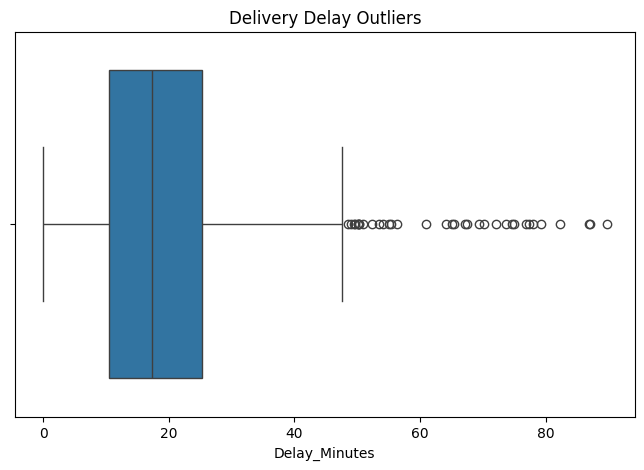

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Delay_Minutes"]
)

plt.title("Delivery Delay Outliers")
plt.show()

In [23]:
Q1 = df["Delay_Minutes"].quantile(0.25)
Q3 = df["Delay_Minutes"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Delay_Minutes"] < lower) |
    (df["Delay_Minutes"] > upper)
]

print("Outliers:", len(outliers))

outliers.head()

Outliers: 35


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Expected_Time,Delay_Minutes
28,903,4.04,Snowy,Low,Night,Bike,11,9.0,70,19.08,50.92
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,46.10,76.90
31,140,19.45,Rainy,High,Morning,Scooter,20,6.0,108,58.90,49.10
73,742,6.38,Snowy,Low,Evening,Bike,16,1.0,111,28.76,82.24
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,62.94,78.06


In [24]:
z = np.abs(
    stats.zscore(
        df["Delay_Minutes"]
    )
)

outliers_z = df[z > 3]

outliers_z.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Expected_Time,Delay_Minutes
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,46.10,76.90
73,742,6.38,Snowy,Low,Evening,Bike,16,1.0,111,28.76,82.24
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,62.94,78.06
133,996,2.29,Rainy,High,Afternoon,Car,8,8.0,80,12.58,67.42
140,45,5.55,Foggy,High,Evening,Bike,18,1.0,116,29.10,86.90


In [25]:
outliers[
[
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Preparation_Time_min",
    "Delay_Minutes"
]
].head(20)

,Distance_km,Weather,Traffic_Level,Preparation_Time_min,Delay_Minutes
28,4.04,Snowy,Low,11,50.92
29,18.05,Clear,Medium,10,76.90
31,19.45,Rainy,High,20,49.10
73,6.38,Snowy,Low,16,82.24
127,18.97,Clear,Low,25,78.06
133,2.29,Rainy,High,8,67.42
136,16.25,Foggy,High,10,48.50
140,5.55,Foggy,High,18,86.90
149,14.43,Clear,Medium,14,70.14
195,18.15,Rainy,High,22,49.70


In [26]:
corr_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delay_Minutes"
]

corr = df[corr_cols].corr()

corr

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delay_Minutes
Distance_km,1.000000,-0.009037,-0.007842,0.444399
Preparation_Time_min,-0.009037,1.000000,-0.030830,-0.024007
Courier_Experience_yrs,-0.007842,-0.030830,1.000000,-0.126072
Delay_Minutes,0.444399,-0.024007,-0.126072,1.000000


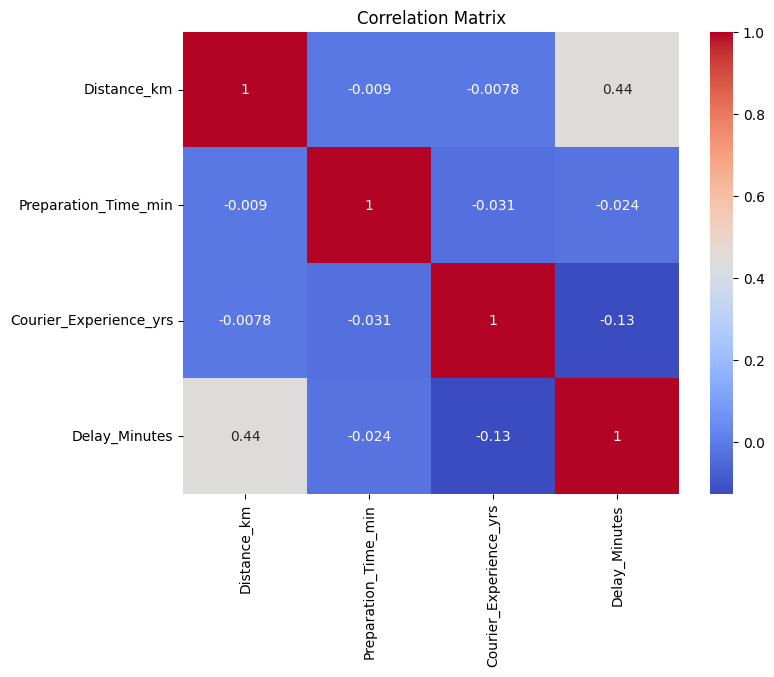

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

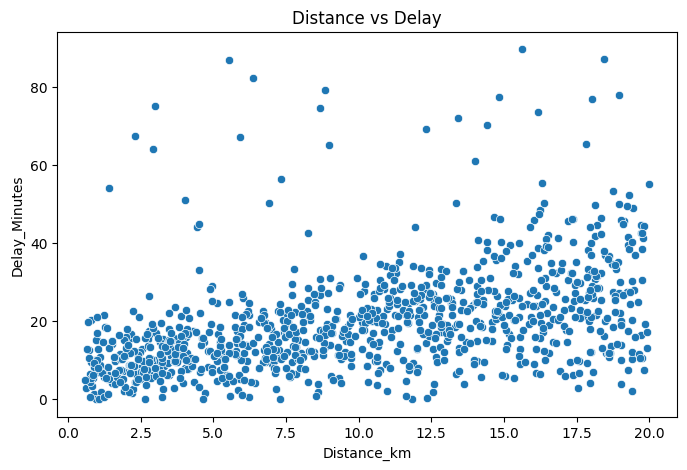

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Distance_km",
    y="Delay_Minutes",
    data=df
)

plt.title("Distance vs Delay")
plt.show()

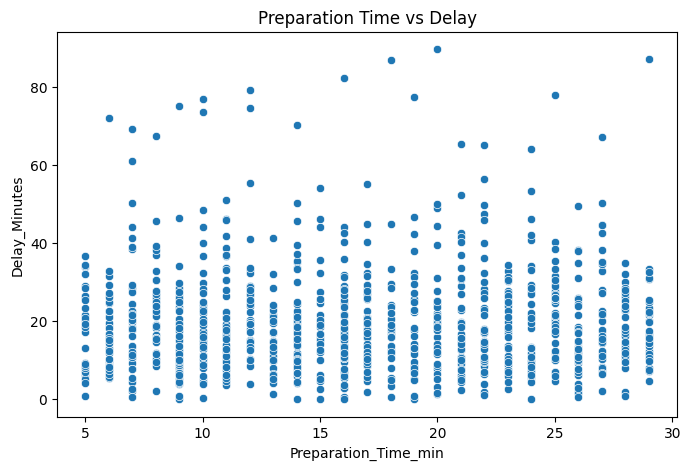

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Preparation_Time_min",
    y="Delay_Minutes",
    data=df
)

plt.title("Preparation Time vs Delay")
plt.show()

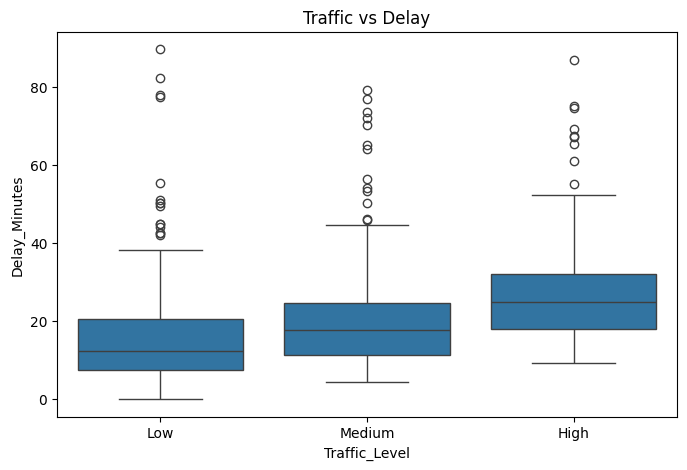

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Traffic_Level",
    y="Delay_Minutes",
    data=df
)

plt.title("Traffic vs Delay")
plt.show()

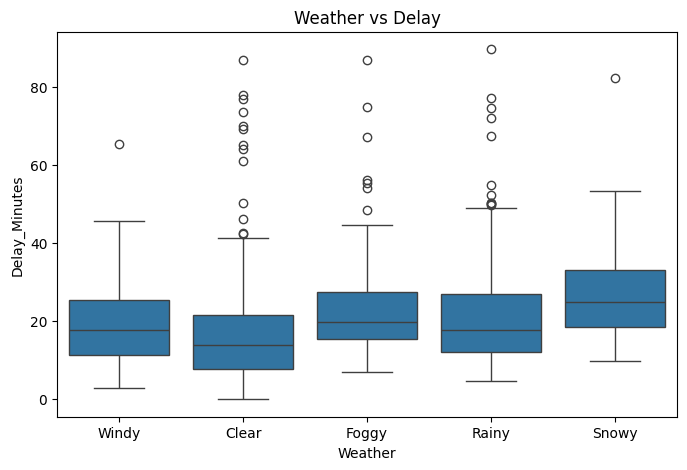

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Weather",
    y="Delay_Minutes",
    data=df
)

plt.title("Weather vs Delay")
plt.show()

In [33]:
from scipy.stats import f_oneway

# Remove rows where Weather is missing
df_anova = df.dropna(subset=["Weather"])

groups = []

for weather in df_anova["Weather"].unique():

    g = df_anova[
        df_anova["Weather"] == weather
    ]["Delay_Minutes"]

    print(weather, len(g))

    if len(g) > 1:
        groups.append(g)

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

Windy 96
Clear 470
Foggy 103
Rainy 204
Snowy 97
F-statistic: 20.690370692465493
P-value: 2.2393297106910624e-16


In [34]:
corr["Delay_Minutes"].sort_values(
    ascending=False
)

Delay_Minutes             1.000000
Distance_km               0.444399
Preparation_Time_min     -0.024007
Courier_Experience_yrs   -0.126072
Name: Delay_Minutes, dtype: float64

In [35]:
df.groupby(
    "Traffic_Level"
)["Delay_Minutes"].mean().sort_values(
    ascending=False
)

Traffic_Level
High      27.176548
Medium    19.800359
Low       15.348198
Name: Delay_Minutes, dtype: float64

In [36]:
df.groupby(
    "Weather"
)["Delay_Minutes"].mean()

Weather
Clear    16.235319
Foggy    23.599806
Rainy    21.795882
Snowy    27.068041
Windy    19.453750
Name: Delay_Minutes, dtype: float64

In [37]:
df[
[
    "Courier_Experience_yrs",
    "Delay_Minutes"
]
].corr()

,Courier_Experience_yrs,Delay_Minutes
Courier_Experience_yrs,1.000000,-0.126072
Delay_Minutes,-0.126072,1.000000


In [38]:
top_delay = df.sort_values(
    "Delay_Minutes",
    ascending=False
).head(10)

top_delay

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Expected_Time,Delay_Minutes
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141,51.28,89.72
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153,65.92,87.08
140,45,5.55,Foggy,High,Evening,Bike,18,1.0,116,29.10,86.90
73,742,6.38,Snowy,Low,Evening,Bike,16,1.0,111,28.76,82.24
343,126,8.83,NaN,Medium,Evening,Scooter,12,3.0,109,29.66,79.34
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,62.94,78.06
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126,48.66,77.34
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,46.10,76.90
859,773,2.99,Foggy,High,Afternoon,Bike,9,5.0,90,14.98,75.02
735,836,8.67,Rainy,High,Afternoon,Bike,12,7.0,104,29.34,74.66


In [39]:
df.groupby(
    "Time_of_Day"
)["Delay_Minutes"].mean()

Time_of_Day
Afternoon    19.202465
Evening      20.230990
Morning      18.935260
Night        19.040941
Name: Delay_Minutes, dtype: float64